# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [3]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

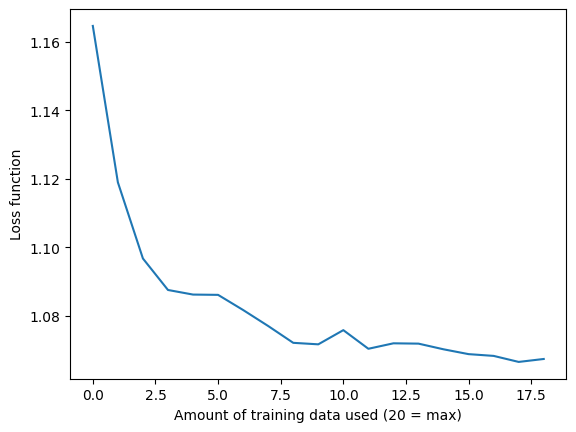

In [4]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [5]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

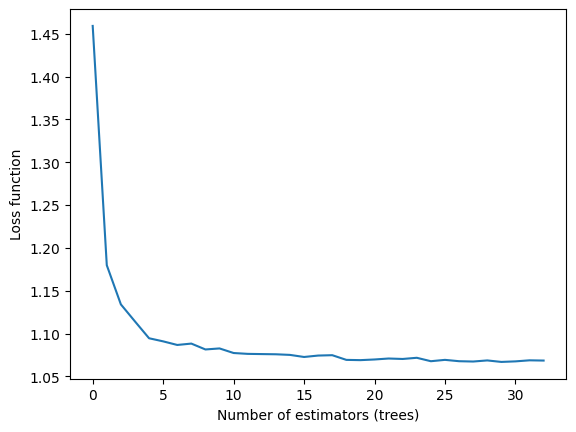

In [6]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

I would choose to keep the Number of Estimators plot because it provides a much clearer picture of the model's convergence and architectural efficiency. While the training data plot is hindered by the noise inherent in a small sample size, the estimator plot showcases a textbook stabilization of the loss function. By analyzing this trend, I can confidently determine that the model reaches its peak performance around 15 trees, allowing me to justify my hyperparameter tuning and avoid unnecessary computational costs. Ultimately, this visualization transforms a simple observation into an actionable insight regarding the model’s learning capacity.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

C:\Users\peace\AppData\Local\Temp\ipykernel_4544\3069380719.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['$0', '$100', '$200', '$300', '$400', '$500'])


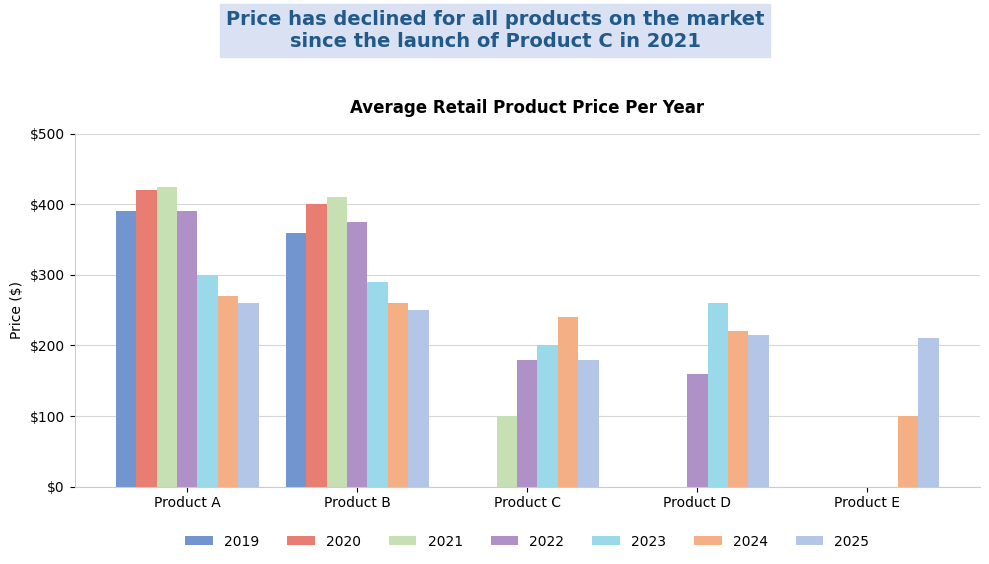

In [7]:
# --- 1. Data Setup ---
# Products on the x-axis
products = ['Product A', 'Product B', 'Product C', 'Product D', 'Product E']
# Years for the grouped bars
years = ['2019', '2020', '2021', '2022', '2023', '2024', '2025']

# Mock data reflecting the general trends in the image
# (A & B declining, C peaking then dropping, D & E starting late)
data = {
    '2019': [390, 360, 0, 0, 0],
    '2020': [420, 400, 0, 0, 0],
    '2021': [425, 410, 100, 0, 0],
    '2022': [390, 375, 180, 160, 0],
    '2023': [300, 290, 200, 260, 0],
    '2024': [270, 260, 240, 220, 100],
    '2025': [260, 250, 180, 215, 210]
}

# --- 2. Styling ---
# Approximating the colors from the image
colors = ['#7294CF', '#E87D72', '#C6E0B4', '#AF91C8', '#99D9EA', '#F4B084', '#B4C6E7']

x = np.arange(len(products))  # Label locations
width = 0.12  # Width of each individual bar

fig, ax = plt.subplots(figsize=(10, 6))

# --- 3. Plotting ---
for i, year in enumerate(years):
    # Offset each year's bar group
    offset = (i - len(years)/2) * width + (width/2)
    ax.bar(x + offset, data[year], width, label=year, color=colors[i], edgecolor='none')

# --- 4. Customizing the "Look and Feel" ---
# Title with a background box (simulating the blue banner)
fig.suptitle('Price has declined for all products on the market\nsince the launch of Product C in 2021', 
             fontsize=14, fontweight='bold', color='#215989', backgroundcolor='#D9E1F2', y=0.98)

ax.set_title('Average Retail Product Price Per Year', fontsize=12, fontweight='bold', pad=15)

# Axis labels and ticks
ax.set_ylabel('Price ($)', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(products)
ax.set_ylim(0, 500)

# Formatting the Y-axis to show dollar signs
ax.set_yticklabels(['$0', '$100', '$200', '$300', '$400', '$500'])

# Grid and Spines
ax.yaxis.grid(True, linestyle='-', alpha=0.5)
ax.set_axisbelow(True) # Ensure grid is behind bars
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# Legend at the bottom
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=len(years), frameon=False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()